In [7]:
import numpy as np
import matplotlib.pyplot as plt

* Parámetros

In [160]:
class Escenario:
    def __init__(self, R_0, F_0, h):
        self.R_0 = R_0
        self.F_0 = F_0
        self.t_final = 16
        self.h = h
        self.t = np.arange(0, self.t_final + self.h, self.h)
        
        self.R = np.zeros(len(self.t))
        self.F = np.zeros(len(self.t))
        
        self.R[0] = R_0
        self.F[0] = F_0

        self.alfa  = 2
        self.beta  = 1.5
        self.gamma = 1
        self.delta = 0.8

        for n in range(len(self.t) - 1):
            dR = (
                self.alfa * self.R[n] * (1 - self.R[n] / 2.5) 
                - self.beta * self.R[n] * self.F[n]
            )
            dF = (
                -self.gamma * self.F[n] 
                + self.delta * self.R[n] * self.F[n]
            )
            self.R[n+1] = self.R[n] + self.h * dR
            self.F[n+1] = self.F[n] + self.h * dF
            
    def grafica(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.t, self.R, label=f'Presa (R_0 = {self.R_0})')
        plt.plot(self.t, self.F, label=f'Depredador (F_0 = {self.F_0})')
        plt.xlabel("t")
        plt.ylabel("Población")
        plt.title("Modelo depredador-presa — Método de Euler")
        plt.legend()
        plt.grid()
        plt.show()

    def retrato(self):
        
        dx = np.diff(self.R)
        dy = np.diff(self.F)
        paso = 100
        xs = self.R[paso::paso]
        ys = self.F[paso::paso]
        dxs = dx[paso::paso]
        dys = dy[paso::paso]

        R_0 = round(self.R_0, 4)
        F_0 = round(self.F_0, 4)
        
        plt.plot(self.R, self.F, label = f'R_0 = {R_0} y F_0 = {F_0}')
        plt.quiver(xs, ys, dxs, dys, angles="xy", scale=0.3, width=0.005, zorder=0)

    def p_equilibrio(self):
        
        R_eq = round(self.R[0], 6)
        F_eq = round(self.F[0], 6)
        h = self.h
        i = 1
        
        while  True:

            dR = self.alfa * R_eq * (1 - R_eq / 2.5) - self.beta * R_eq * F_eq
            dF = -self.gamma * F_eq + self.delta * R_eq * F_eq
            
            R_nuevo = round(R_eq + h * dR, 6)
            F_nuevo = round(F_eq + h * dF, 6)

            i += 1

            if R_nuevo == R_eq and F_nuevo == F_eq:
                break
                
            F_eq = F_nuevo
            R_eq = R_nuevo
            
        return(f'puntos de equilibrio: R_eq = {R_eq} (Presa) F_eq = {F_eq} (Depredador). Con {i} iteraciones')

In [161]:
caso1 = Escenario(R_0 = 0.2, F_0 = 1.5, h = 0.01)
caso2 = Escenario(R_0 = 2.2, F_0 = 2.0, h = 0.01)
caso3 = Escenario(R_0 = 2.1, F_0 = 0.8, h = 0.01)
caso4 = Escenario(R_0 = 5/4, F_0 = 6/9, h = 0.01)

* Retrato de fase

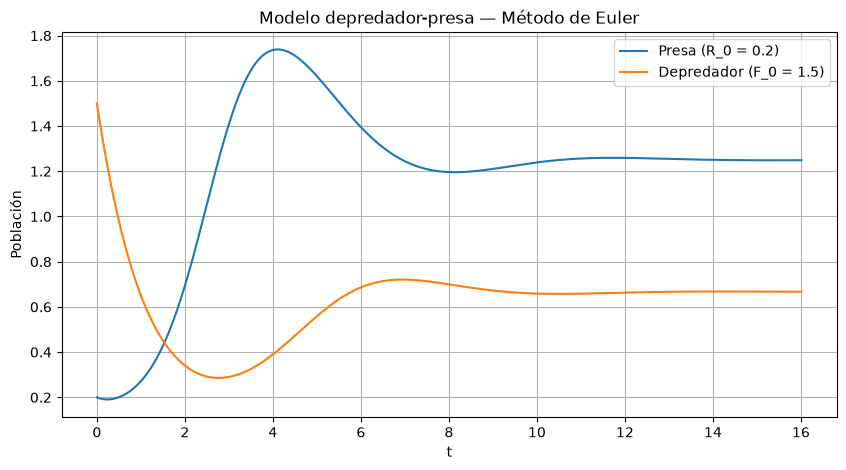

In [16]:
caso1.grafica()

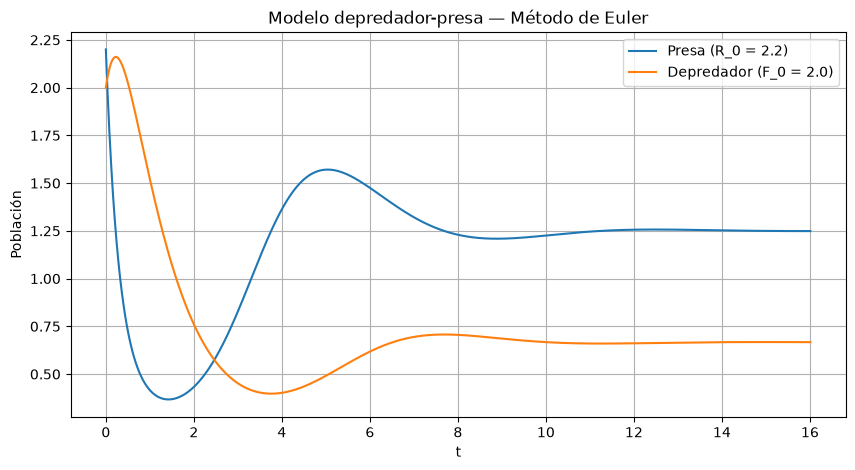

In [17]:
caso2.grafica()

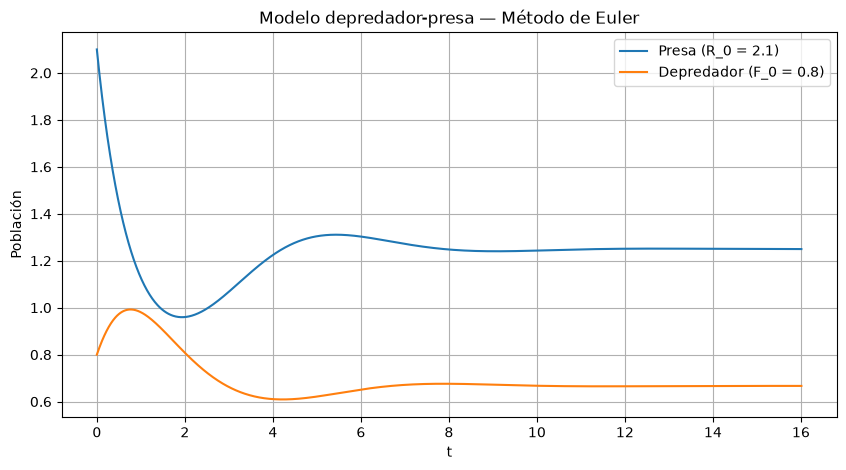

In [18]:
caso3.grafica()

* Tomar una muestra para el Retrato de fase

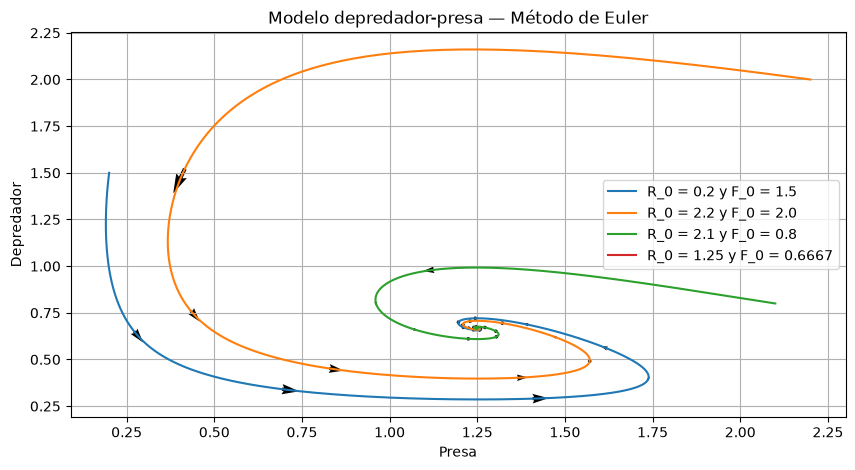

In [162]:
plt.figure(figsize=(10, 5))

caso1.retrato(); caso2.retrato(); caso3.retrato(); caso4.retrato()

plt.xlabel("Presa")
plt.ylabel("Depredador")
plt.title("Modelo depredador-presa — Método de Euler")
plt.legend()
plt.grid()

plt.show()

# Punto de equilibrio del sistema de ED

In [163]:
caso1.p_equilibrio()

'puntos de equilibrio: R_eq = 1.249993 (Presa) F_eq = 0.666697 (Depredador). Con 2181 iteraciones'

In [164]:
caso2.p_equilibrio()

'puntos de equilibrio: R_eq = 1.250008 (Presa) F_eq = 0.666689 (Depredador). Con 2180 iteraciones'

In [165]:
caso3.p_equilibrio()

'puntos de equilibrio: R_eq = 1.250008 (Presa) F_eq = 0.666636 (Depredador). Con 1920 iteraciones'

In [166]:
caso4.p_equilibrio()

'puntos de equilibrio: R_eq = 1.25 (Presa) F_eq = 0.666667 (Depredador). Con 2 iteraciones'